In [1]:
# import numpy as np
import numpy as np
import nnfs
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data

nnfs.init()


class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases


class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)


class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities


In [ ]:
# Generate Sample Data
Feature, categories = spiral_data(samples=100, classes=3)


plt.scatter(Feature[:, 0], Feature[:, 1], c=categories, cmap='brg')

plt.show()

print("Feature: ", np.shape(Feature))
print("categories: ", np.shape(categories))



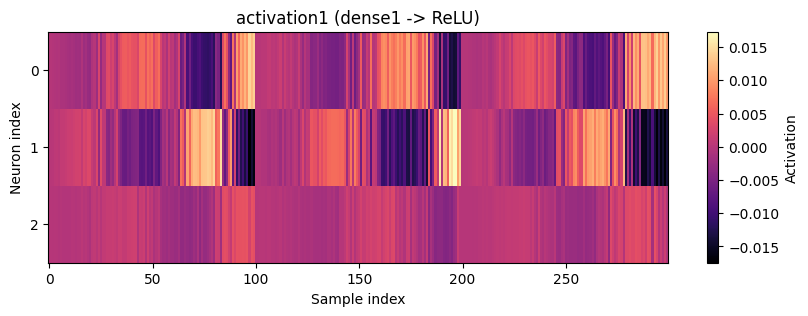

In [3]:
# Create 2x3 Hidden Neural Network
dense1 = Layer_Dense(2, 3)
dense1.forward(Feature)
activation1 = Activation_ReLU()
activation1.forward(dense1.output)

plt.figure(figsize=(10, 3))
im = plt.imshow(
    dense1.output.T, aspect="auto", cmap="magma", interpolation="nearest"
)
plt.title("activation1 (dense1 -> ReLU)")
plt.ylabel("Neuron index")
plt.xlabel("Sample index")
plt.yticks(range(dense1.output.shape[1]))
plt.colorbar(im, label="Activation")
plt.show()

In [4]:
# Create 3x3 Output Layer
dense2 = Layer_Dense(3, 3)
dense2.forward(activation1.output)
activation2 = Activation_Softmax()
activation2.forward(dense2.output)

print(activation2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333316 0.3333332  0.33333364]
 [0.33333287 0.3333329  0.33333418]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]
